<a href="https://colab.research.google.com/github/DewyV3582/Stock-Price-Dashboard-/blob/main/Copy_of_Wheel_Strategy_Options_Backtester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wheel Strategy Options Backtester

Simulates selling cash-secured puts on a rolling monthly basis, using Black-Scholes
options pricing and historical stock volatility to estimate realistic premium collection
and assignment risk over time.

Built with: yfinance, pandas, numpy, scipy, matplotlib

## Known limitations
- Assumes a fixed strike % (10% OTM) and fixed 30-day expiration cycle
- Does not account for rolling positions or reacting to price movement, unlike real trading
- Uses a static risk-free rate approximation

## Usage
Set `ticker`, run all cells — outputs a table of simulated cycles plus summary stats
(total premium, assignment rate).

In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
ticker = "RIVN"
data = yf.download(ticker, period="1y", interval="1d")
data.head()

/tmp/ipykernel_1668/3039762873.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RIVN,RIVN,RIVN,RIVN,RIVN
Date,,,,,
2025-08-21,12.12,12.15,11.840,12.04,42737000
2025-08-22,13.09,13.11,12.160,12.17,64603100
2025-08-25,13.11,13.49,12.910,13.05,46841300
2025-08-26,13.21,13.26,12.840,13.11,53099500
2025-08-27,13.22,13.50,13.135,13.25,38969800


In [ ]:
data['Daily_Return'] = data['Close'].pct_change()
data['Volatility_20d'] = data['Daily_Return'].rolling(window=20).std() * np.sqrt(252)

data[['Close', 'Volatility_20d']].tail(10)

Price,Close,Volatility_20d
Ticker,RIVN,
Date,,
2026-08-10,16.389999,0.556042
2026-08-11,16.360001,0.553892
2026-08-12,15.930000,0.554635
2026-08-13,15.820000,0.539214
2026-08-14,15.360000,0.538354
2026-08-17,14.870000,0.545926
2026-08-18,14.780000,0.528261
2026-08-19,15.730000,0.579311


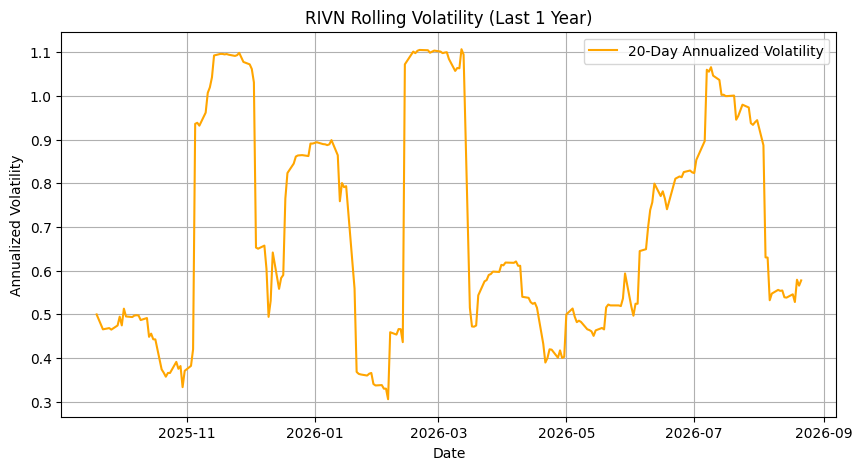

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data['Volatility_20d'], color='orange', label='20-Day Annualized Volatility')
plt.title(f'{ticker} Rolling Volatility (Last 1 Year)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def estimate_put_premium(price, strike, volatility, days_to_exp=30):
    # Simple approximation: premium scales with volatility, time, and distance from strike
    time_factor = np.sqrt(days_to_exp / 365)
    moneyness = (price - strike) / price  # how far OTM the put is

    premium = price * volatility * time_factor * 0.4  # 0.4 is a rough scaling constant
    premium = premium * max(0.1, (1 - moneyness * 2))  # reduce premium for deep OTM puts

    return round(premium, 2)

In [ ]:
current_price = data['Close'].iloc[-1].item()
current_vol = data['Volatility_20d'].iloc[-1].item()
test_strike = current_price * 0.90

premium = estimate_put_premium(current_price, test_strike, current_vol)
print(f"Price: ${current_price:.2f}, Strike: ${test_strike:.2f}, Estimated Premium: ${premium:.2f}")

Price: $16.84, Strike: $15.16, Estimated Premium: $0.89


In [ ]:
results = []

for i in range(0, len(data) - 30, 21):  # step every ~21 trading days (~1 month)
    entry_date = data.index[i]
    entry_price = data['Close'].iloc[i].item()
    vol = data['Volatility_20d'].iloc[i].item()

    if pd.isna(vol):
        continue  # skip early rows before volatility can be calculated

    strike = entry_price * 0.90  # 10% OTM put
    premium = estimate_put_premium(entry_price, strike, vol)

    exit_price = data['Close'].iloc[i + 30].item()
    assigned = exit_price < strike

    results.append({
        'entry_date': entry_date,
        'entry_price': entry_price,
        'strike': round(strike, 2),
        'premium': premium,
        'exit_price': round(exit_price, 2),
        'assigned': assigned
        })

results_df = pd.DataFrame(results)
results_df


,entry_date,entry_price,strike,premium,exit_price,assigned
0,2025-09-22,15.240000,13.72,0.65,13.19,True
1,2025-10-21,13.200000,11.88,0.44,17.53,False
2,2025-11-19,14.720000,13.25,1.48,19.59,False
3,2025-12-19,22.450001,20.21,1.70,14.37,True
4,2026-01-22,16.320000,14.69,0.54,15.37,False
5,2026-02-23,14.960000,13.46,1.52,14.69,False
6,2026-03-24,16.100000,14.49,0.85,14.48,True
7,2026-04-23,16.950001,15.26,0.65,16.35,False
8,2026-05-22,14.220000,12.80,0.68,16.66,False
9,2026-06-24,14.640000,13.18,1.10,15.38,False


In [ ]:
total_premium = results_df['premium'].sum()
num_cycles = len(results_df)
num_assigned = results_df['assigned'].sum()
assignment_rate = num_assigned / num_cycles * 100

print(f"Total cycles simulated: {num_cycles}")
print(f"Total premium collected: ${total_premium:.2f}")
print(f"Times assigned: {num_assigned} ({assignment_rate:.1f}%)")
print(f"Average premium per cycle: ${total_premium/num_cycles:.2f}")

Total cycles simulated: 10
Total premium collected: $9.61
Times assigned: 3 (30.0%)
Average premium per cycle: $0.96


In [ ]:
from scipy.stats import norm

def black_scholes_put(S, K, T, r, sigma):
    """
    S = current stock price
    K = strike price
    T = time to expiration (in years)
    r = risk-free interest rate (as a decimal, e.g. 0.05 for 5%)
    sigma = volatility (as a decimal, e.g. 0.60 for 60%)
    """
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return round(put_price, 2)

In [ ]:
r = 0.05  # approximate risk-free rate (current T-bill yields)
T = 30/365  # 30 days to expiration, converted to years

premium_bs = black_scholes_put(current_price, test_strike, T, r, current_vol)
print(f"Black-Scholes Premium: ${premium_bs:.2f}")
print(f"Our simple formula gave: ${estimate_put_premium(current_price, test_strike, current_vol)}")

Black-Scholes Premium: $0.40
Our simple formula gave: $0.89


In [ ]:
results_bs = []

for i in range(0, len(data) - 30, 21):
    entry_date = data.index[i]
    entry_price = data['Close'].iloc[i].item()
    vol = data['Volatility_20d'].iloc[i].item()

    if pd.isna(vol):
        continue

    strike = entry_price * 0.90
    T = 30/365
    premium = black_scholes_put(entry_price, strike, T, r, vol)

    exit_price = data['Close'].iloc[i + 30].item()
    assigned = exit_price < strike

    results_bs.append({
        'entry_date': entry_date,
        'entry_price': round(entry_price, 2),
        'strike': round(strike, 2),
        'premium': premium,
        'exit_price': round(exit_price, 2),
        'assigned': assigned
    })

results_bs_df = pd.DataFrame(results_bs)
results_bs_df

,entry_date,entry_price,strike,premium,exit_price,assigned
0,2025-09-22,15.24,13.72,0.22,13.19,True
1,2025-10-21,13.20,11.88,0.10,17.53,False
2,2025-11-19,14.72,13.25,1.08,19.59,False
3,2025-12-19,22.45,20.21,1.05,14.37,True
4,2026-01-22,16.32,14.69,0.12,15.37,False
5,2026-02-23,14.96,13.46,1.11,14.69,False
6,2026-03-24,16.10,14.49,0.39,14.48,True
7,2026-04-23,16.95,15.26,0.19,16.35,False
8,2026-05-22,14.22,12.80,0.27,16.66,False
9,2026-06-24,14.64,13.18,0.67,15.38,False


In [ ]:
total_premium_bs = results_bs_df['premium'].sum()
num_cycles_bs = len(results_bs_df)
num_assigned_bs = results_bs_df['assigned'].sum()
assignment_rate_bs = num_assigned_bs / num_cycles_bs * 100

print(f"Total cycles simulated: {num_cycles_bs}")
print(f"Total premium collected: ${total_premium_bs:.2f}")
print(f"Times assigned: {num_assigned_bs} ({assignment_rate_bs:.1f}%)")
print(f"Average premium per cycle: ${total_premium_bs/num_cycles_bs:.2f}")

Total cycles simulated: 10
Total premium collected: $5.20
Times assigned: 3 (30.0%)
Average premium per cycle: $0.52
